# Guía 2 — Campo eléctrico, superposición y ley de Gauss

## Campo eléctrico de una carga puntual

Si una carga puntual $q$ se encuentra en la posición $\vec r_0$, el campo eléctrico que produce en un punto $\vec r$ viene dado por

\begin{equation*}
\vec E(\vec r)=\frac{1}{4\pi\varepsilon_0}\,q\,\frac{\vec r-\vec r_0}{|\vec r-\vec r_0|^3}.
\end{equation*}

Esta expresión contiene dos ideas que conviene retener:

1. la dirección del campo coincide con la del vector $\vec r-\vec r_0$ si $q>0$, y es opuesta si $q<0$;
2. la magnitud del campo decrece como $1/r^2$ con la distancia a la carga.


## Principio de superposición

Si el sistema contiene varias cargas puntuales, el campo total en un punto se obtiene sumando vectorialmente los campos individuales:

\begin{equation*}
\vec E_{\mathrm{tot}}(\vec r)=
\sum_{i=1}^{N}
\frac{1}{4\pi\varepsilon_0}\,q_i\,\frac{\vec r-\vec r_i}{|\vec r-\vec r_i|^3}.
\end{equation*}

En los problemas 1 y 2 esta es la herramienta central. En el problema 3 se usa equilibrio de fuerzas, y en el problema 8 se aplica ley de Gauss junto con las propiedades electrostáticas de los conductores.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Rectangle, Wedge
from matplotlib.colors import LogNorm
import sympy as sp

k = 8.9875517923e9  # N m^2 / C^2

def field_from_charge(q, pos, X, Y, soften=1e-18):
    x0, y0 = pos
    dx = X - x0
    dy = Y - y0
    r2 = dx**2 + dy**2
    r = np.sqrt(r2)
    r3 = np.where(r > 0, r2 * r, np.inf)
    Ex = k * q * dx / (r3 + soften)
    Ey = k * q * dy / (r3 + soften)
    return Ex, Ey, r

def field_from_charges(charges, X, Y):
    Ex = np.zeros_like(X, dtype=float)
    Ey = np.zeros_like(Y, dtype=float)
    rmin = np.full_like(X, np.inf, dtype=float)
    for item in charges:
        ex, ey, r = field_from_charge(item["q"], item["pos"], X, Y)
        Ex += ex
        Ey += ey
        rmin = np.minimum(rmin, r)
    return Ex, Ey, rmin

def make_grid(xmin, xmax, ymin, ymax, n=300):
    xs = np.linspace(xmin, xmax, n)
    ys = np.linspace(ymin, ymax, n)
    X, Y = np.meshgrid(xs, ys)
    return xs, ys, X, Y

def plot_field_map(
    charges,
    xmin, xmax, ymin, ymax,
    title="",
    units="cm",
    n=300,
    charge_radius=0.25,
    mask_radius=0.15,
    observation_points=None,
    annotate=True,
):
    xs_cm, ys_cm, X_cm, Y_cm = make_grid(xmin, xmax, ymin, ymax, n=n)
    X = X_cm / 100.0
    Y = Y_cm / 100.0

    charges_si = []
    for item in charges:
        charges_si.append({
            "q": item["q"],
            "pos": (item["pos"][0] / 100.0, item["pos"][1] / 100.0),
            "label": item.get("label", ""),
        })

    Ex, Ey, _ = field_from_charges(charges_si, X, Y)
    Emag = np.sqrt(Ex**2 + Ey**2)

    mask = np.zeros_like(Emag, dtype=bool)
    for item in charges_si:
        x0, y0 = item["pos"]
        rr = np.sqrt((X - x0)**2 + (Y - y0)**2)
        mask |= rr < (mask_radius / 100.0)

    Emag_masked = np.ma.array(Emag, mask=mask)
    Ex_masked = np.ma.array(Ex, mask=mask)
    Ey_masked = np.ma.array(Ey, mask=mask)

    positive_values = Emag_masked.compressed()
    vmin = max(np.percentile(positive_values, 10), 1e2) if positive_values.size else 1e2
    vmax = max(np.percentile(positive_values, 99.5), vmin * 10) if positive_values.size else 1e6

    fig, ax = plt.subplots(figsize=(8, 6))
    pcm = ax.pcolormesh(
        X_cm, Y_cm, Emag_masked,
        shading="auto",
        norm=LogNorm(vmin=vmin, vmax=vmax),
        cmap="viridis"
    )

    ax.streamplot(
        xs_cm, ys_cm,
        Ex_masked, Ey_masked,
        color="white",
        density=1.2,
        linewidth=0.8,
        arrowsize=0.9
    )

    for item in charges:
        x0, y0 = item["pos"]
        color = "crimson" if item["q"] > 0 else "royalblue"
        circ = Circle((x0, y0), charge_radius, facecolor=color, edgecolor="black", lw=1.2, zorder=5)
        ax.add_patch(circ)
        if annotate:
            sign = "+" if item["q"] > 0 else "−"
            label = item.get("label", "")
            ax.text(x0, y0 + 0.45, f"{label} {sign}".strip(), ha="center", va="bottom", fontsize=10)

    if observation_points:
        for p in observation_points:
            ax.plot(p["x"], p["y"], marker="o", color="black", ms=5, zorder=6)
            ax.text(p["x"] + 0.15, p["y"] + 0.15, p.get("label", ""), fontsize=10)

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_xlabel(f"$x$ ({units})")
    ax.set_ylabel(f"$y$ ({units})")
    ax.set_title(title)
    ax.set_aspect("equal", adjustable="box")
    cbar = fig.colorbar(pcm, ax=ax)
    cbar.set_label(r"$|\vec E|$ [N/C] (escala logarítmica)")
    plt.show()

def electric_field_at_point(charges, point_m):
    Ex = 0.0
    Ey = 0.0
    x, y = point_m
    for item in charges:
        x0, y0 = item["pos"]
        dx = x - x0
        dy = y - y0
        r2 = dx*dx + dy*dy
        r = np.sqrt(r2)
        Ex += k * item["q"] * dx / (r2 * r)
        Ey += k * item["q"] * dy / (r2 * r)
    return Ex, Ey

def print_vector(name, Ex, Ey):
    mag = float(np.sqrt(Ex**2 + Ey**2))
    print(f"{name}:")
    print(f"  Ex = {Ex:.6e} N/C")
    print(f"  Ey = {Ey:.6e} N/C")
    print(f"  |E| = {mag:.6e} N/C")
    print()

def draw_problem1_geometry():
    fig, ax = plt.subplots(figsize=(10, 2.8))
    ax.annotate("", xy=(9.2, 0), xytext=(-0.8, 0), arrowprops=dict(arrowstyle="->", lw=1.6))
    xs = [0, 3, 6, 8]
    labels = [
        r"$q_1=16\times 10^{-9}\,\mathrm{C}$",
        r"$q_2=q$",
        r"$q_3=12\times 10^{-9}\,\mathrm{C}$",
        r"$P$",
    ]
    colors = ["crimson", "gray", "crimson", "black"]
    sizes = [220, 220, 220, 70]
    for x, lab, col, s in zip(xs, labels, colors, sizes):
        ax.scatter([x], [0], s=s, c=col, edgecolors="black", zorder=3)
        if x == 8:
            ax.text(x, 0.45, lab, ha="center", fontsize=12)
        else:
            ax.text(x, 0.48, lab, ha="center", fontsize=11)
        ax.text(x, -0.35, f"{x}", ha="center", fontsize=10)
        ax.plot([x, x], [-0.08, 0.08], color="black", lw=1)
    ax.annotate("", xy=(8.9, 0.85), xytext=(8.1, 0.85), arrowprops=dict(arrowstyle="->", lw=1.8))
    ax.text(8.95, 1.0, r"$\vec E_{\mathrm{tot}}(P)=2\times 10^5\,\hat x\ \mathrm{N/C}$", fontsize=11, ha="right")
    ax.set_xlim(-0.8, 9.3)
    ax.set_ylim(-0.8, 1.4)
    ax.set_title("Problema 1 — configuración sobre la recta real")
    ax.set_xlabel(r"$x$ (cm)")
    ax.set_yticks([])
    ax.spines[['left','right','top']].set_visible(False)
    plt.show()

def draw_problem2_geometry():
    fig, ax = plt.subplots(figsize=(6.5, 6.5))
    ax.axhline(0, color="black", lw=1.2)
    ax.axvline(0, color="black", lw=1.2)
    points = [
        (0, 3, r"$q_1=5\times 10^{-7}\,\mathrm{C}$", "crimson"),
        (0, -3, r"$q_2=15\times 10^{-7}\,\mathrm{C}$", "crimson"),
        (6, 0, r"$P=(6,0)\,\mathrm{cm}$", "black"),
    ]
    for x, y, lab, col in points:
        ax.scatter([x], [y], s=180 if col=="crimson" else 60, c=col, edgecolors="black", zorder=3)
        ax.text(x + 0.25, y + 0.25, lab, fontsize=11)
    ax.plot([0, 6], [3, 0], ls="--", lw=1.2)
    ax.plot([0, 6], [-3, 0], ls="--", lw=1.2)
    ax.text(2.4, 1.9, r"$\vec r_P-\vec r_1$", fontsize=11)
    ax.text(2.2, -1.9, r"$\vec r_P-\vec r_2$", fontsize=11)
    ax.set_xlim(-1.5, 8)
    ax.set_ylim(-5, 5)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel(r"$x$ (cm)")
    ax.set_ylabel(r"$y$ (cm)")
    ax.set_title("Problema 2 — geometría del sistema")
    plt.show()

def draw_problem3_setup():
    fig, ax = plt.subplots(figsize=(7,5))
    ax.add_patch(Rectangle((-2.5, -1.9), 5.0, 0.35, facecolor="#ffdddd", edgecolor="black"))
    ax.add_patch(Rectangle((-2.5,  1.55), 5.0, 0.35, facecolor="#dde7ff", edgecolor="black"))
    for x in np.linspace(-2.0, 2.0, 5):
        ax.text(x, -1.72, "+", ha="center", va="center", fontsize=14)
        ax.text(x,  1.72, "−", ha="center", va="center", fontsize=14)
    drop = Circle((0,0), 0.28, facecolor="lightgray", edgecolor="black", lw=1.3)
    ax.add_patch(drop)
    ax.text(0,0,r"$q$", ha="center", va="center", fontsize=12)
    for x in np.linspace(-1.7, 1.7, 5):
        ax.arrow(x, -1.2, 0, 2.2, head_width=0.08, head_length=0.12, length_includes_head=True)
    ax.text(1.95, 0.25, r"$\vec E$", fontsize=12)
    ax.arrow(0, 0.32, 0, 1.0, head_width=0.09, head_length=0.13, length_includes_head=True, linewidth=2)
    ax.text(0.1, 1.35, r"$\vec F_e=q\vec E$", fontsize=12)
    ax.arrow(0, -0.32, 0, -1.0, head_width=0.09, head_length=0.13, length_includes_head=True, linewidth=2)
    ax.text(0.15, -1.45, r"$\vec P=m\vec g$", fontsize=12)
    ax.set_xlim(-2.8, 2.8)
    ax.set_ylim(-2.2, 2.2)
    ax.set_aspect('equal', adjustable='box')
    ax.set_title("Problema 3 — equilibrio entre fuerza eléctrica y peso")
    ax.axis('off')
    plt.show()

def draw_problem8_base(ax):
    inner = Circle((0, 0), 1.0, facecolor='lightgray', edgecolor='black', hatch='///', lw=1.8, alpha=0.85)
    shell2 = Wedge((0, 0), 3.0, 0, 360, width=1.0, facecolor='lightgray', edgecolor='black', hatch='///', lw=1.8, alpha=0.85)
    shell3 = Wedge((0, 0), 5.0, 0, 360, width=1.0, facecolor='lightgray', edgecolor='black', hatch='///', lw=1.8, alpha=0.85)
    for patch in [inner, shell2, shell3]:
        ax.add_patch(patch)
    for rr in [1, 2, 3, 4, 5]:
        ax.add_patch(Circle((0, 0), rr, fill=False, edgecolor='black', lw=1.8))
    ax.annotate("", xy=(5.8, 0), xytext=(-5.8, 0), arrowprops=dict(arrowstyle="->", lw=1.2))
    ax.annotate("", xy=(0, 5.8), xytext=(0, -5.8), arrowprops=dict(arrowstyle="->", lw=1.2))
    ax.text(5.95, -0.15, r"$x$", fontsize=11)
    ax.text(0.18, 5.65, r"$y$", fontsize=11)
    for rr, lab in [(1, r"$a$"), (2, r"$2a$"), (3, r"$3a$"), (4, r"$4a$"), (5, r"$5a$")]:
        ax.text(rr/np.sqrt(2)+0.1, -rr/np.sqrt(2)-0.12, lab, fontsize=11)

def draw_problem8_global_unknown():
    fig, ax = plt.subplots(figsize=(7, 7))
    draw_problem8_base(ax)
    for rr, lab in [(1, r"$Q_a$"), (2, r"$Q_{2a}$"), (3, r"$Q_{3a}$"), (4, r"$Q_{4a}$"), (5, r"$Q_{5a}$")]:
        x = rr/np.sqrt(2)
        y = rr/np.sqrt(2)
        ax.text(x+0.18, y+0.18, lab, fontsize=12)
    ax.set_xlim(-6, 6)
    ax.set_ylim(-6, 6)
    ax.set_aspect("equal", adjustable="box")
    ax.set_title("Problema 8 — superficies con cargas desconocidas")
    ax.axis("off")
    plt.show()

def draw_problem8_gauss_inner():
    fig, ax = plt.subplots(figsize=(8.5, 7))
    draw_problem8_base(ax)
    rg = 2.5
    ax.add_patch(Circle((0, 0), rg, fill=False, edgecolor='navy', lw=2.2, ls=':'))
    for rr, lab in [(1, r"$Q_a=Q$"), (2, r"$Q_{2a}$")]:
        x = rr*np.cos(np.deg2rad(140))
        y = rr*np.sin(np.deg2rad(140))
        ax.text(x-0.4, y+0.15, lab, fontsize=11)
    ax.annotate(r"$\partial V_2$", xy=(rg*np.cos(np.deg2rad(20)), rg*np.sin(np.deg2rad(20))),
                xytext=(4.0, 2.7), arrowprops=dict(arrowstyle="->", lw=1.5), fontsize=12)
    ax.text(3.6, -1.0, r"$\vec E=\vec 0$ en el metal", fontsize=11)
    ax.text(3.6, -1.7, r"$Q_{\mathrm{enc}}=Q_a+Q_{2a}=0$", fontsize=11)
    ax.set_xlim(-6, 6)
    ax.set_ylim(-6, 6)
    ax.set_aspect("equal", adjustable="box")
    ax.set_title(r"Problema 8 — superficie gaussiana con $2a<r<3a$")
    ax.axis("off")
    plt.show()

def draw_problem8_gauss_outer():
    fig, ax = plt.subplots(figsize=(8.5, 7))
    draw_problem8_base(ax)
    rg = 4.5
    ax.add_patch(Circle((0, 0), rg, fill=False, edgecolor='navy', lw=2.2, ls=':'))
    for rr, lab, ang in [(1, r"$Q_a=Q$", 145), (2, r"$Q_{2a}=-Q$", 152), (3, r"$Q_{3a}=-Q$", 160), (4, r"$Q_{4a}$", 168)]:
        x = rr*np.cos(np.deg2rad(ang))
        y = rr*np.sin(np.deg2rad(ang))
        ax.text(x-0.6, y+0.12, lab, fontsize=11)
    ax.annotate(r"$\partial V_3$", xy=(rg*np.cos(np.deg2rad(20)), rg*np.sin(np.deg2rad(20))),
                xytext=(4.4, 3.0), arrowprops=dict(arrowstyle="->", lw=1.5), fontsize=12)
    ax.text(3.7, -0.8, r"$\vec E=\vec 0$ en el metal", fontsize=11)
    ax.text(3.7, -1.5, r"$Q_{\mathrm{enc}}=Q_a+Q_{2a}+Q_{3a}+Q_{4a}=0$", fontsize=11)
    ax.set_xlim(-6, 6)
    ax.set_ylim(-6, 6)
    ax.set_aspect("equal", adjustable="box")
    ax.set_title(r"Problema 8 — superficie gaussiana con $4a<r<5a$")
    ax.axis("off")
    plt.show()

def draw_problem8_final_distribution():
    fig, ax = plt.subplots(figsize=(7, 7))
    draw_problem8_base(ax)
    for rr, lab in [(1, r"$Q_a=Q$"), (2, r"$Q_{2a}=-Q$"), (3, r"$Q_{3a}=-Q$"), (4, r"$Q_{4a}=Q$"), (5, r"$Q_{5a}=-Q$")]:
        x = rr/np.sqrt(2)
        y = rr/np.sqrt(2)
        ax.text(x+0.15, y+0.15, lab, fontsize=11)
    ax.set_xlim(-6, 6)
    ax.set_ylim(-6, 6)
    ax.set_aspect("equal", adjustable="box")
    ax.set_title("Problema 8 — distribución final de carga")
    ax.axis("off")
    plt.show()

---

# Problema 1

Una carga de $16\times 10^{-9}\,\mathrm{C}$ está fija en el origen del eje $x$; una segunda carga, desconocida, está en $x=3\,\mathrm{cm}$; y una tercera, de $12\times 10^{-9}\,\mathrm{C}$, está en $x=6\,\mathrm{cm}$. Se sabe que el campo total en $x=8\,\mathrm{cm}$ es $2\times 10^5\,\mathrm{N/C}$ hacia la derecha. Se pide determinar la carga desconocida.


## Figura 1.1 — configuración geométrica

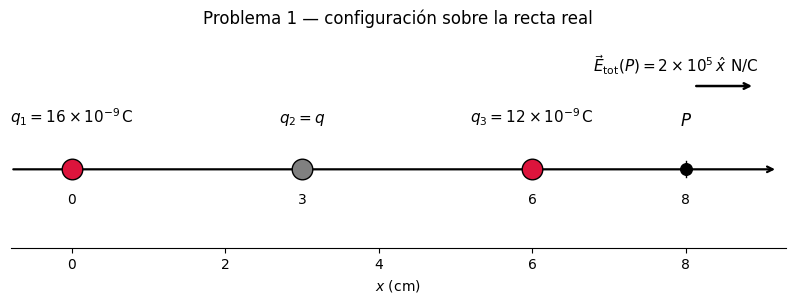

In [2]:
draw_problem1_geometry()

## Desarrollo

Como todas las cargas y la posición de observación están sobre el eje $x$, conviene describir el problema sobre una sola recta. Introducimos

\begin{equation*}
q_1=16\times 10^{-9}\,\mathrm{C},\qquad
q_2=q,\qquad
q_3=12\times 10^{-9}\,\mathrm{C},
\end{equation*}

y tomamos como posiciones

\begin{equation*}
\vec r_1=(0,0)\,\mathrm{cm},\qquad
\vec r_2=(3,0)\,\mathrm{cm},\qquad
\vec r_3=(6,0)\,\mathrm{cm},\qquad
\vec r_P=(8,0)\,\mathrm{cm}.
\end{equation*}

Las distancias desde cada carga hasta el punto de observación son

\begin{equation*}
|\vec r_P-\vec r_1|=8\,\mathrm{cm}=0.08\,\mathrm{m},\qquad
|\vec r_P-\vec r_2|=5\,\mathrm{cm}=0.05\,\mathrm{m},\qquad
|\vec r_P-\vec r_3|=2\,\mathrm{cm}=0.02\,\mathrm{m}.
\end{equation*}

Como $q_1$ y $q_3$ son positivas y están a la izquierda de $\vec r_P$, ambas contribuciones apuntan hacia $+\hat x$. Entonces, por superposición,

\begin{equation*}
E_{\mathrm{tot}}(\vec r_P)=
k\frac{16\times 10^{-9}}{(0.08)^2}
+
k\frac{q}{(0.05)^2}
+
k\frac{12\times 10^{-9}}{(0.02)^2}.
\end{equation*}

El enunciado indica que

\begin{equation*}
E_{\mathrm{tot}}(\vec r_P)=2\times 10^{5}\,\mathrm{N/C},
\end{equation*}

de modo que debemos resolver

\begin{equation*}
2\times 10^{5}
=
k\frac{16\times 10^{-9}}{(0.08)^2}
+
k\frac{q}{(0.05)^2}
+
k\frac{12\times 10^{-9}}{(0.02)^2}.
\end{equation*}


In [3]:
q = sp.symbols('q', real=True)

eq = sp.Eq(
    2e5,
    k*(16e-9/(0.08**2) + q/(0.05**2) + 12e-9/(0.02**2))
)

q_sol = sp.solve(eq, q)[0]
q_sol

-2.56174972278468e-8

In [4]:
q_sol_n = float(q_sol)
print(f"q = {q_sol_n:.6e} C")
print(f"q = {q_sol_n*1e9:.3f} nC")

q = -2.561750e-08 C
q = -25.617 nC


Por lo tanto,

\begin{equation*}
\boxed{q\approx -2.57\times 10^{-8}\,\mathrm{C}=-25.7\;\mathrm{nC}.}
\end{equation*}

El signo negativo muestra que la carga ubicada en $x=3\,\mathrm{cm}$ debe producir en $P$ un campo dirigido hacia la izquierda, de modo de compensar parcialmente el aporte de las otras dos cargas.


## Visualización del problema 1

### Figura 1.2 — campo producido por $q_1$

Antes de sumar los campos, conviene mirar por separado la contribución de cada carga. Así se ve con claridad la dirección del campo que genera cada una.


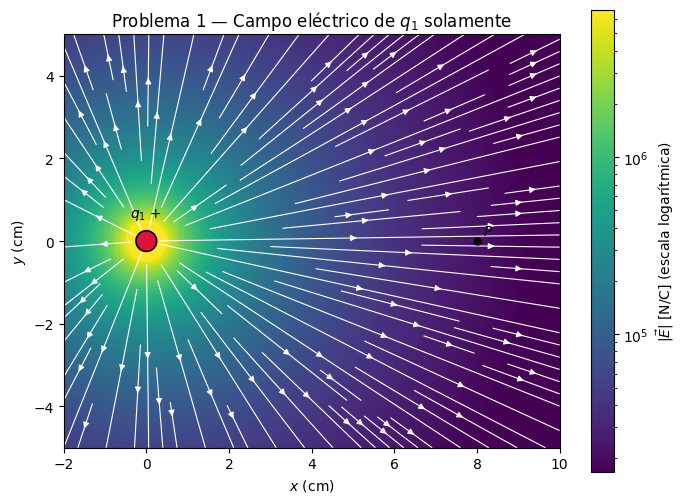

In [5]:
charges_p1_q1 = [
    {"q": 16e-9, "pos": (0.0, 0.0), "label": r"$q_1$"},
]

plot_field_map(
    charges_p1_q1,
    xmin=-2, xmax=10, ymin=-5, ymax=5,
    title="Problema 1 — Campo eléctrico de $q_1$ solamente",
    observation_points=[{"x": 8, "y": 0, "label": r"$P$"}],
    n=280
)

### Figura 1.3 — campo producido por $q_2$

Una vez determinado el signo de la carga desconocida, su campo puede compararse con los de $q_1$ y $q_3$.


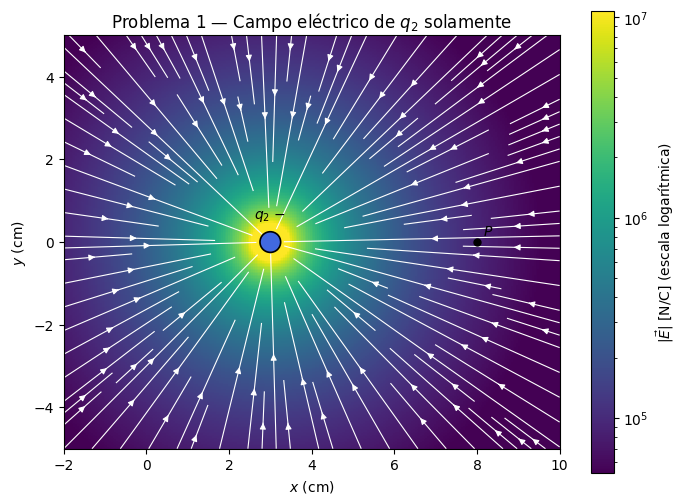

In [6]:
charges_p1_q2 = [
    {"q": float(q_sol_n), "pos": (3.0, 0.0), "label": r"$q_2$"},
]

plot_field_map(
    charges_p1_q2,
    xmin=-2, xmax=10, ymin=-5, ymax=5,
    title="Problema 1 — Campo eléctrico de $q_2$ solamente",
    observation_points=[{"x": 8, "y": 0, "label": r"$P$"}],
    n=280
)

### Figura 1.4 — campo producido por $q_3$

Como $q_3$ es positiva y está ubicada a la izquierda de la región mostrada, el campo apunta radialmente alejándose de ella.


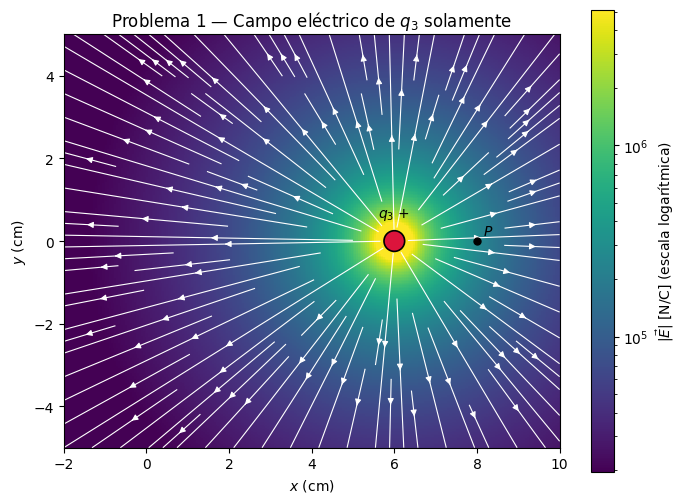

In [7]:
charges_p1_q3 = [
    {"q": 12e-9, "pos": (6.0, 0.0), "label": r"$q_3$"},
]

plot_field_map(
    charges_p1_q3,
    xmin=-2, xmax=10, ymin=-5, ymax=5,
    title="Problema 1 — Campo eléctrico de $q_3$ solamente",
    observation_points=[{"x": 8, "y": 0, "label": r"$P$"}],
    n=280
)

### Figura 1.5 — superposición de los tres campos

La figura siguiente muestra el campo total

\begin{equation*}
\vec E_{\mathrm{tot}}=\vec E_1+\vec E_2+\vec E_3.
\end{equation*}

Esta visualización permite comparar las contribuciones individuales con el campo resultante.


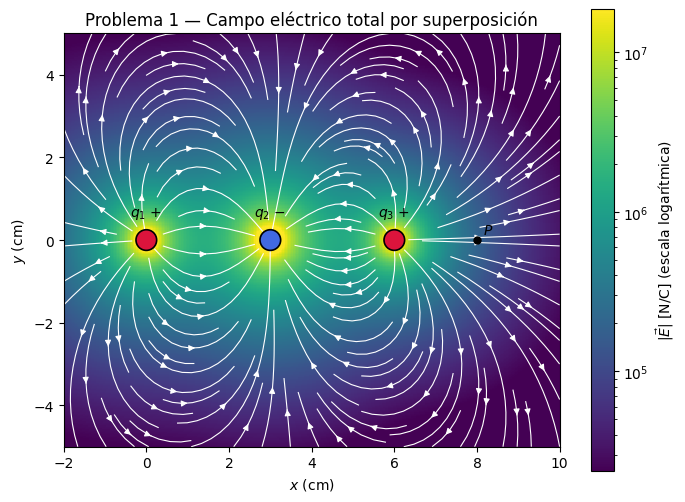

In [8]:
charges_p1_total = [
    {"q": 16e-9, "pos": (0.0, 0.0), "label": r"$q_1$"},
    {"q": float(q_sol_n), "pos": (3.0, 0.0), "label": r"$q_2$"},
    {"q": 12e-9, "pos": (6.0, 0.0), "label": r"$q_3$"},
]

plot_field_map(
    charges_p1_total,
    xmin=-2, xmax=10, ymin=-5, ymax=5,
    title="Problema 1 — Campo eléctrico total por superposición",
    observation_points=[{"x": 8, "y": 0, "label": r"$P$"}],
    n=320
)

In [9]:
charges_p1_si = [
    {"q": 16e-9, "pos": (0.00, 0.00)},
    {"q": float(q_sol_n), "pos": (0.03, 0.00)},
    {"q": 12e-9, "pos": (0.06, 0.00)},
]

Ex, Ey = electric_field_at_point(charges_p1_si, (0.08, 0.00))
print_vector("Campo total en P", Ex, Ey)

Campo total en P:
  Ex = 2.000000e+05 N/C
  Ey = 0.000000e+00 N/C
  |E| = 2.000000e+05 N/C



---

# Problema 2

En el sistema de la figura, las cargas puntuales son

\begin{equation*}
q_1=5\times 10^{-7}\,\mathrm{C},\qquad
q_2=15\times 10^{-7}\,\mathrm{C}.
\end{equation*}

Se pide:

1. el campo eléctrico en el punto $P=(6,0)\,\mathrm{cm}$;
2. los puntos del eje $Y$ donde el campo es nulo.


## Figura 2.1 — geometría del problema 2

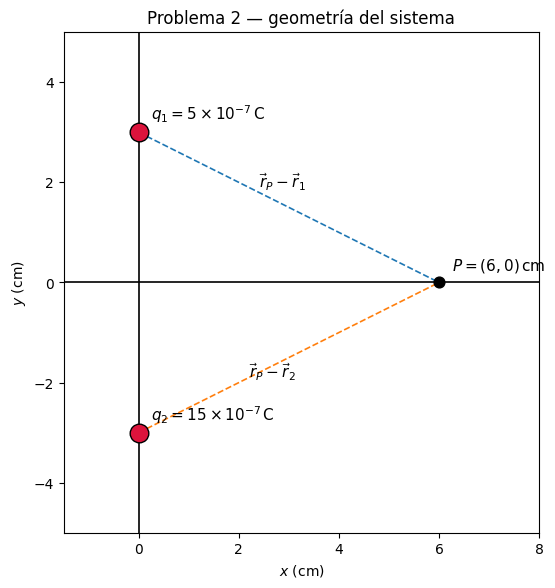

In [10]:
draw_problem2_geometry()

## Desarrollo de la parte (a)

Las posiciones de las cargas y del punto de observación son

\begin{equation*}
\vec r_1=(0,3)\,\mathrm{cm},\qquad
\vec r_2=(0,-3)\,\mathrm{cm},\qquad
\vec r_P=(6,0)\,\mathrm{cm}.
\end{equation*}

Aplicamos la expresión vectorial del campo eléctrico de una carga puntual:

\begin{equation*}
\vec E(\vec r)=kq\,\frac{\vec r-\vec r_0}{|\vec r-\vec r_0|^3}.
\end{equation*}

Por superposición,

\begin{equation*}
\vec E(\vec r_P)=
kq_1\frac{\vec r_P-\vec r_1}{|\vec r_P-\vec r_1|^3}
+
kq_2\frac{\vec r_P-\vec r_2}{|\vec r_P-\vec r_2|^3}.
\end{equation*}

Los vectores desde cada carga hasta el punto de observación son

\begin{equation*}
\vec r_P-\vec r_1=(6,-3)\,\mathrm{cm},\qquad
\vec r_P-\vec r_2=(6,3)\,\mathrm{cm},
\end{equation*}

y sus módulos coinciden:

\begin{equation*}
|\vec r_P-\vec r_1|=|\vec r_P-\vec r_2|=\sqrt{45}\,\mathrm{cm}=3\sqrt{5}\,\mathrm{cm}.
\end{equation*}

Por eso puede escribirse

\begin{equation*}
\vec E(\vec r_P)=
k\,\frac{q_1(6,-3)+q_2(6,3)}{(3\sqrt{5}\times 10^{-2})^3}.
\end{equation*}


In [11]:
charges_p2_si = [
    {"q": 5e-7,  "pos": (0.00, 0.03)},
    {"q": 15e-7, "pos": (0.00, -0.03)},
]

Ex_p2, Ey_p2 = electric_field_at_point(charges_p2_si, (0.06, 0.00))
print_vector("Campo en P del problema 2(a)", Ex_p2, Ey_p2)

Campo en P del problema 2(a):
  Ex = 3.572760e+06 N/C
  Ey = 8.931901e+05 N/C
  |E| = 3.682717e+06 N/C



Por lo tanto,

\begin{equation*}
\boxed{
\vec E(\vec r_P)\approx
(3.58\,\hat x+0.89\,\hat y)\times 10^6\;\mathrm{N/C}.
}
\end{equation*}

La componente en $x$ es positiva porque ambas cargas empujan el campo hacia la derecha en $\vec r_P$, mientras que la componente vertical resulta positiva porque la contribución de $q_2$ domina sobre la de $q_1$.


## Desarrollo de la parte (b)

Buscamos los puntos del eje $Y$ donde el campo total se anula. Tomamos un punto genérico

\begin{equation*}
\vec r=(0,y).
\end{equation*}

Entonces,

\begin{equation*}
\vec r-\vec r_1=(0,y-3)\,\mathrm{cm},\qquad
\vec r-\vec r_2=(0,y+3)\,\mathrm{cm}.
\end{equation*}

Sobre el eje $Y$, el campo total sólo tiene componente vertical. Antes de igualar magnitudes, conviene analizar el sentido de los campos:

- si $y>3$, ambos campos apuntan hacia arriba;
- si $y<-3$, ambos campos apuntan hacia abajo;
- por lo tanto, la anulación sólo puede ocurrir en el intervalo $-3<y<3$.

En ese intervalo, el campo de $q_1$ apunta hacia abajo y el de $q_2$ hacia arriba. La condición de cancelación es entonces

\begin{equation*}
\frac{kq_1}{(3-y)^2}=
\frac{kq_2}{(y+3)^2}.
\end{equation*}

Sustituyendo los valores dados,

\begin{equation*}
\frac{5}{(3-y)^2}=\frac{15}{(y+3)^2}.
\end{equation*}


In [12]:
y = sp.symbols('y', real=True)
sol_y = sp.solve(sp.Eq(5/(3-y)**2, 15/(y+3)**2), y)
sol_y

[6 - 3*sqrt(3), 3*sqrt(3) + 6]

In [13]:
sol_y_n = float(3*(2-np.sqrt(3)))
print(f"y = {sol_y_n:.6f} cm")

y = 0.803848 cm


Numéricamente,

\begin{equation*}
\boxed{y\approx 0.804\;\mathrm{cm}.}
\end{equation*}

Ese es el único punto del eje $Y$ en el cual el campo total se anula.


## Visualización del problema 2

### Figura 2.2 — campo total en el plano

El mapa de colores representa la magnitud del campo y las líneas indican su dirección.


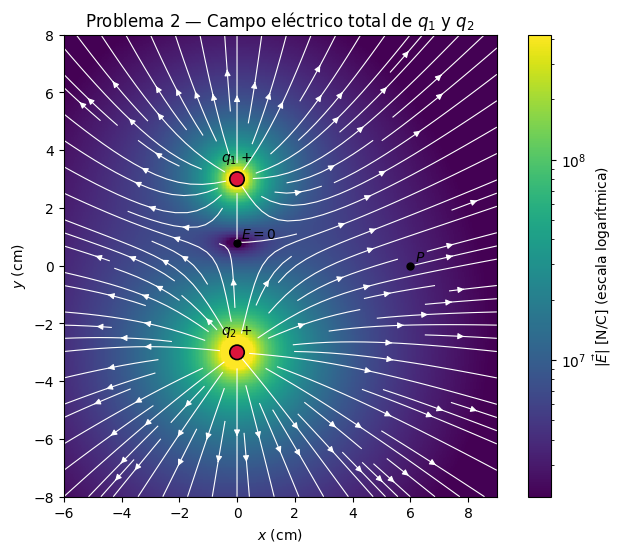

In [14]:
charges_p2_plot = [
    {"q": 5e-7,  "pos": (0.0,  3.0), "label": r"$q_1$"},
    {"q": 15e-7, "pos": (0.0, -3.0), "label": r"$q_2$"},
]

plot_field_map(
    charges_p2_plot,
    xmin=-6, xmax=9, ymin=-8, ymax=8,
    title="Problema 2 — Campo eléctrico total de $q_1$ y $q_2$",
    observation_points=[
        {"x": 6, "y": 0, "label": r"$P$"},
        {"x": 0, "y": float(3*(2-np.sqrt(3))), "label": r"$E=0$"},
    ],
    n=320
)

### Figura 2.3 — componente $E_y$ sobre el eje $Y$

Este gráfico permite identificar con claridad el punto donde la componente vertical cambia de signo y, por tanto, donde el campo se anula sobre el eje $Y$.


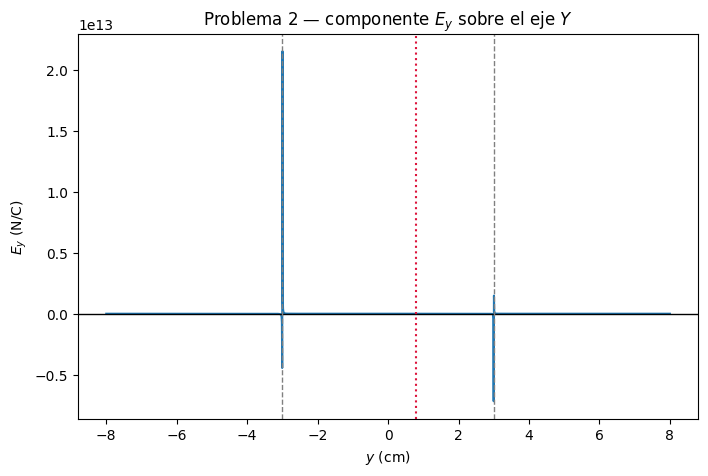

In [15]:
y_cm = np.linspace(-8, 8, 2000)
y_m = y_cm / 100.0

Ey_axis = np.zeros_like(y_m)
for i, yy in enumerate(y_m):
    if abs(yy - 0.03) < 1e-6 or abs(yy + 0.03) < 1e-6:
        Ey_axis[i] = np.nan
    else:
        _, Eytemp = electric_field_at_point(charges_p2_si, (0.0, yy))
        Ey_axis[i] = Eytemp

plt.figure(figsize=(8,5))
plt.plot(y_cm, Ey_axis)
plt.axhline(0, color='black', lw=1)
plt.axvline(3, color='gray', ls='--', lw=1)
plt.axvline(-3, color='gray', ls='--', lw=1)
plt.axvline(float(3*(2-np.sqrt(3))), color='crimson', ls=':', lw=1.5)
plt.xlabel(r"$y$ (cm)")
plt.ylabel(r"$E_y$ (N/C)")
plt.title("Problema 2 — componente $E_y$ sobre el eje $Y$")
plt.show()

---

# Problema 3

Una pequeña gota de aceite esférica, de masa

\begin{equation*}
m=1.0\times 10^{-4}\,\mathrm{g},
\end{equation*}

permanece estacionaria dentro de un campo eléctrico uniforme de magnitud

\begin{equation*}
E=2\times 10^2\;\mathrm{N/C}.
\end{equation*}

Se pide encontrar la carga de la gota.


## Figura 3.1 — equilibrio entre fuerza eléctrica y peso

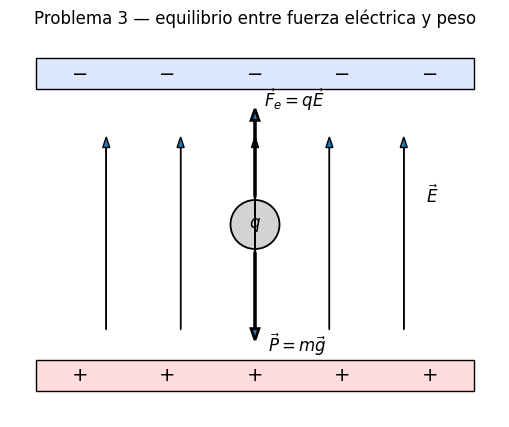

In [16]:
draw_problem3_setup()

## Desarrollo

La gota permanece en reposo, de modo que la fuerza neta sobre ella es nula:

\begin{equation*}
\vec F_e+\vec P=\vec 0.
\end{equation*}

En consecuencia, las magnitudes de ambas fuerzas deben coincidir:

\begin{equation*}
|\vec F_e|=|\vec P|.
\end{equation*}

Usando

\begin{equation*}
|\vec F_e|=|q|E,
\qquad
|\vec P|=mg,
\end{equation*}

obtenemos

\begin{equation*}
|q|E=mg,
\end{equation*}

y por tanto

\begin{equation*}
|q|=\frac{mg}{E}.
\end{equation*}

Con

\begin{equation*}
m=1.0\times 10^{-7}\,\mathrm{kg},\qquad
g=9.8\,\mathrm{m/s^2},\qquad
E=2.0\times 10^2\,\mathrm{N/C},
\end{equation*}

se determina la magnitud de la carga.


In [17]:
m = 1.0e-7  # kg
g = 9.8
E = 2.0e2
q_abs = m*g/E
print(f"|q| = {q_abs:.6e} C")
print(f"|q| = {q_abs*1e9:.3f} nC")

|q| = 4.900000e-09 C
|q| = 4.900 nC


Por lo tanto,

\begin{equation*}
\boxed{|q|=4.90\times 10^{-9}\,\mathrm{C}=4.90\;\mathrm{nC}.}
\end{equation*}

El cálculo anterior entrega primero la magnitud. El signo se fija comparando la dirección del campo con la dirección de la fuerza eléctrica necesaria para equilibrar el peso. Si el campo eléctrico apunta hacia arriba, la carga debe ser positiva.


---

# Problema 8

La figura muestra tres conductores esféricos concéntricos:

1. una esfera maciza de radio $a$ con carga neta $Q$;
2. un cascarón de radios $2a$ y $3a$ con carga neta $-2Q$;
3. un cascarón de radios $4a$ y $5a$ con carga neta total nula.

Se pide resolver los siguientes ítems:

1. determinar la ubicación, magnitud y signo de la carga en cada superficie;
2. encontrar la densidad superficial de carga correspondiente a cada una de esas superficies.


## Ideas físicas usadas

El razonamiento del problema se apoya en tres hechos fundamentales:

1. **En equilibrio electrostático, el campo eléctrico dentro del material conductor es nulo.**
2. **Si una superficie gaussiana cerrada está completamente contenida en una región metálica, entonces la carga neta encerrada por ella debe ser cero.** En efecto,

\begin{equation*}
\vec E=\vec 0
\quad\Longrightarrow\quad
\oint_{\partial V}\vec E\cdot \hat n\,dA=0
\quad\Longrightarrow\quad
Q_{\mathrm{enc}}=0.
\end{equation*}

3. **Por simetría esférica, la carga se distribuye uniformemente sobre cada superficie esférica.**

Una observación pedagógica importante es que aquí la ley de Gauss se usa primero para determinar **cómo se reparte la carga** entre superficies internas y externas; solo después puede emplearse para describir el campo por regiones.


## Figuras del problema 8

Las siguientes figuras resumen la geometría del sistema y las superficies gaussianas que permiten determinar la distribución de carga.


### Figura 8.1 — geometría global y notación de las cargas superficiales


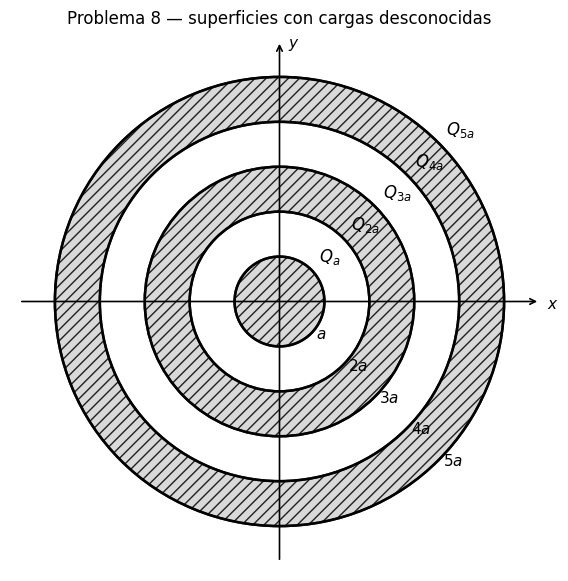

In [18]:
draw_problem8_global_unknown()

### Figura 8.2 — superficie gaussiana con $2a<r<3a$

Tomamos una superficie gaussiana esférica completamente contenida en el material del cascarón intermedio. Como en esa región el sistema está dentro del metal,

\begin{equation*}
\vec E=\vec 0.
\end{equation*}

Entonces el flujo eléctrico a través de la superficie es nulo:

\begin{equation*}
\oint_{\partial V_2}\vec E\cdot \hat n\,dA=0.
\end{equation*}

Por la ley de Gauss,

\begin{equation*}
Q_{\mathrm{enc}}(\partial V_2)=0.
\end{equation*}

Pero la carga encerrada por esa superficie es precisamente

\begin{equation*}
Q_{\mathrm{enc}}(\partial V_2)=Q_a+Q_{2a}.
\end{equation*}

Por tanto,

\begin{equation*}
Q_a+Q_{2a}=0.
\end{equation*}

Esta es la ecuación clave para determinar la carga sobre la superficie de radio $2a$.


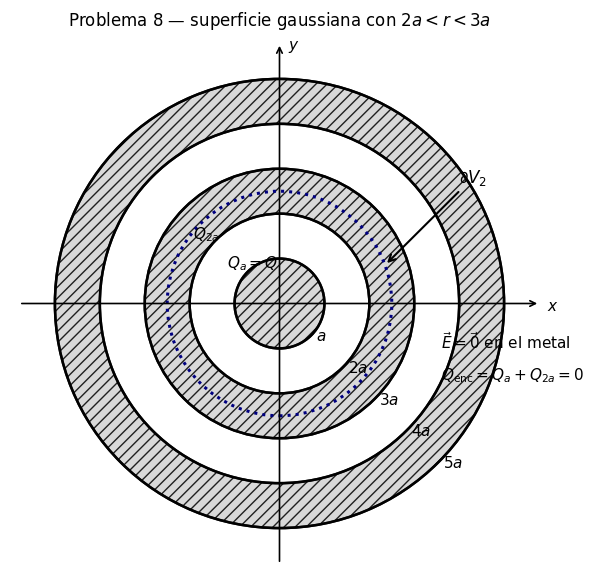

In [19]:
draw_problem8_gauss_inner()

### Figura 8.3 — superficie gaussiana con $4a<r<5a$

Ahora tomamos una segunda superficie gaussiana completamente contenida en el material del cascarón externo. Nuevamente,

\begin{equation*}
\vec E=\vec 0
\qquad\text{en todo punto de la superficie.}
\end{equation*}

Luego,

\begin{equation*}
\oint_{\partial V_3}\vec E\cdot \hat n\,dA=0
\qquad\Longrightarrow\qquad
Q_{\mathrm{enc}}(\partial V_3)=0.
\end{equation*}

En este caso la carga encerrada es

\begin{equation*}
Q_{\mathrm{enc}}(\partial V_3)=Q_a+Q_{2a}+Q_{3a}+Q_{4a}.
\end{equation*}

Por lo tanto,

\begin{equation*}
Q_a+Q_{2a}+Q_{3a}+Q_{4a}=0.
\end{equation*}

Esta relación permite determinar la carga sobre la superficie de radio $4a$.


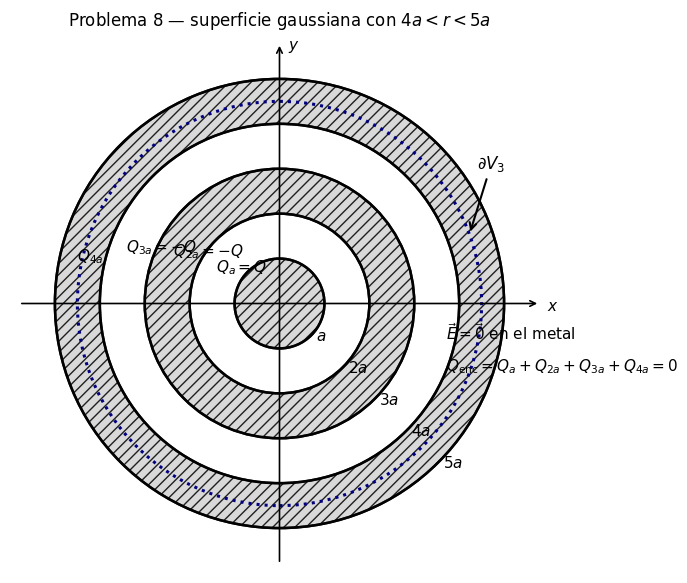

In [20]:
draw_problem8_gauss_outer()

### Figura 8.4 — distribución final de carga

Al resolver sucesivamente las ecuaciones impuestas por la ley de Gauss y por las cargas netas de cada conductor, se obtiene

\begin{equation*}
Q_a=Q,\qquad Q_{2a}=-Q,\qquad Q_{3a}=-Q,\qquad Q_{4a}=Q,\qquad Q_{5a}=-Q.
\end{equation*}

Conviene verificar que estos resultados reproducen las cargas netas dadas en el enunciado:

\begin{align*}
Q_a &= Q,\\
Q_{2a}+Q_{3a} &= (-Q)+(-Q)=-2Q,\\
Q_{4a}+Q_{5a} &= Q+(-Q)=0.
\end{align*}


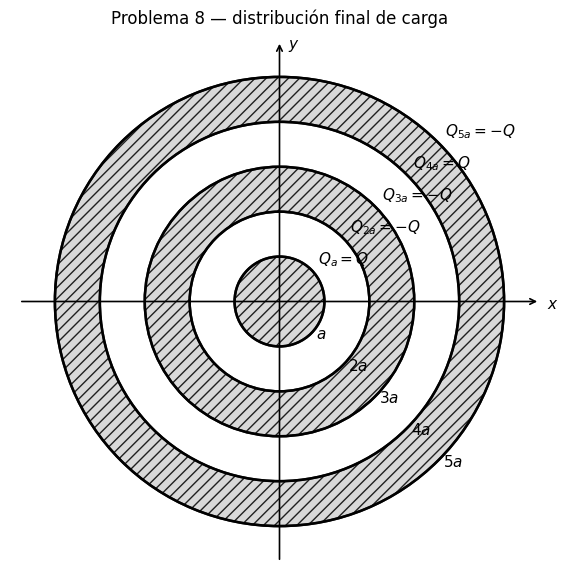

In [21]:
draw_problem8_final_distribution()

## Desarrollo de la parte (a)

Denotemos por

\begin{equation*}
Q_a,\qquad Q_{2a},\qquad Q_{3a},\qquad Q_{4a},\qquad Q_{5a}
\end{equation*}

las cargas depositadas sobre las superficies de radios

\begin{equation*}
a,\qquad 2a,\qquad 3a,\qquad 4a,\qquad 5a.
\end{equation*}

Antes de aplicar la ley de Gauss, registremos las restricciones globales que provienen directamente del enunciado:

\begin{align*}
Q_a &= Q,\\
Q_{2a}+Q_{3a} &= -2Q,\\
Q_{4a}+Q_{5a} &= 0.
\end{align*}

### 1. Esfera conductora de radio $a$

La esfera interior es un conductor macizo sin cavidad. En equilibrio electrostático, toda la carga excedente de un conductor se distribuye sobre su superficie. Como la carga neta total de esta esfera es $Q$, se sigue inmediatamente que

\begin{equation*}
\boxed{Q_a=Q.}
\end{equation*}

### 2. Cascarón de radios $2a$ y $3a$

Para hallar la carga sobre la superficie interna de este cascarón, tomamos una superficie gaussiana esférica de radio $r_g$ tal que

\begin{equation*}
2a<r_g<3a.
\end{equation*}

Como dicha superficie está completamente contenida en el metal,

\begin{equation*}
\vec E=\vec 0
\qquad\Longrightarrow\qquad
Q_{\mathrm{enc}}=0.
\end{equation*}

La carga encerrada por esa superficie es

\begin{equation*}
Q_{\mathrm{enc}}=Q_a+Q_{2a}.
\end{equation*}

Por lo tanto,

\begin{equation*}
Q_a+Q_{2a}=0.
\end{equation*}

Sustituyendo $Q_a=Q$, obtenemos

\begin{equation*}
Q+Q_{2a}=0,
\end{equation*}

de donde

\begin{equation*}
\boxed{Q_{2a}=-Q.}
\end{equation*}

Ahora usamos la carga neta total del cascarón intermedio:

\begin{equation*}
Q_{2a}+Q_{3a}=-2Q.
\end{equation*}

Como $Q_{2a}=-Q$, se sigue que

\begin{equation*}
-Q+Q_{3a}=-2Q,
\end{equation*}

y, en consecuencia,

\begin{equation*}
\boxed{Q_{3a}=-Q.}
\end{equation*}

### 3. Cascarón de radios $4a$ y $5a$

Tomamos ahora una segunda superficie gaussiana esférica de radio $r_g$ tal que

\begin{equation*}
4a<r_g<5a,
\end{equation*}

esto es, completamente contenida en el material del conductor externo.

Una vez más, al estar dentro del metal,

\begin{equation*}
\vec E=\vec 0
\qquad\Longrightarrow\qquad
Q_{\mathrm{enc}}=0.
\end{equation*}

La carga encerrada por esta nueva superficie es

\begin{equation*}
Q_{\mathrm{enc}}=Q_a+Q_{2a}+Q_{3a}+Q_{4a}.
\end{equation*}

Por tanto,

\begin{equation*}
Q_a+Q_{2a}+Q_{3a}+Q_{4a}=0.
\end{equation*}

Sustituyendo los valores ya conocidos,

\begin{equation*}
Q+(-Q)+(-Q)+Q_{4a}=0,
\end{equation*}

de donde se concluye que

\begin{equation*}
\boxed{Q_{4a}=Q.}
\end{equation*}

Finalmente, como el cascarón externo tiene carga neta total nula,

\begin{equation*}
Q_{4a}+Q_{5a}=0.
\end{equation*}

Entonces,

\begin{equation*}
Q+Q_{5a}=0,
\end{equation*}

y así

\begin{equation*}
\boxed{Q_{5a}=-Q.}
\end{equation*}

En conclusión,

\begin{equation*}
\boxed{
Q_a=Q,\qquad
Q_{2a}=-Q,\qquad
Q_{3a}=-Q,\qquad
Q_{4a}=Q,\qquad
Q_{5a}=-Q.
}
\end{equation*}


## Desarrollo de la parte (b)

Como cada superficie es esférica y la distribución de carga es uniforme por simetría, la densidad superficial sobre una esfera de radio $R$ viene dada por

\begin{equation*}
\sigma=\frac{Q_{\mathrm{sup}}}{4\pi R^2}.
\end{equation*}

Aplicamos ahora esta fórmula a cada una de las superficies:

\begin{align*}
\sigma_a &= \frac{Q}{4\pi a^2},\\
\sigma_{2a} &= \frac{-Q}{4\pi(2a)^2}=-\frac{Q}{16\pi a^2},\\
\sigma_{3a} &= \frac{-Q}{4\pi(3a)^2}=-\frac{Q}{36\pi a^2},\\
\sigma_{4a} &= \frac{Q}{4\pi(4a)^2}=\frac{Q}{64\pi a^2},\\
\sigma_{5a} &= \frac{-Q}{4\pi(5a)^2}=-\frac{Q}{100\pi a^2}.
\end{align*}

Por lo tanto,

\begin{equation*}
\boxed{
\sigma_a=\frac{Q}{4\pi a^2},\qquad
\sigma_{2a}=-\frac{Q}{16\pi a^2},\qquad
\sigma_{3a}=-\frac{Q}{36\pi a^2},\qquad
\sigma_{4a}=\frac{Q}{64\pi a^2},\qquad
\sigma_{5a}=-\frac{Q}{100\pi a^2}.
}
\end{equation*}


## Figura 8.5 — campo radial por regiones

Una vez conocida la distribución de carga, el campo radial puede determinarse nuevamente con la ley de Gauss, ahora sí aplicado a regiones del espacio. Definimos la variable adimensional

\begin{equation*}
\rho=\frac{r}{a},
\end{equation*}

y factorizamos la constante común $\dfrac{Q}{4\pi\varepsilon_0 a^2}$. Con esta convención, el campo radial adimensional queda dado por

\begin{equation*}
E_r(\rho)\propto
\begin{cases}
0, & 0<\rho<1,\\[4pt]
+\dfrac{1}{\rho^2}, & 1<\rho<2,\\[8pt]
0, & 2<\rho<3,\\[4pt]
-\dfrac{1}{\rho^2}, & 3<\rho<4,\\[8pt]
0, & 4<\rho<5,\\[4pt]
-\dfrac{1}{\rho^2}, & \rho>5.
\end{cases}
\end{equation*}

La interpretación física de cada tramo es la siguiente:

- en $0<\rho<1$, $2<\rho<3$ y $4<\rho<5$ estamos dentro de material conductor, de modo que el campo es nulo;
- en $1<\rho<2$ la superficie gaussiana encierra una carga neta $Q$, por lo que el campo apunta radialmente hacia afuera;
- en $3<\rho<4$ y en $\rho>5$ la carga neta encerrada es $-Q$, por lo que el campo apunta radialmente hacia adentro.

Esta descripción por regiones ayuda a separar con claridad los intervalos en que el campo desaparece por equilibrio electrostático de aquellos en que vuelve a comportarse como $1/r^2$.


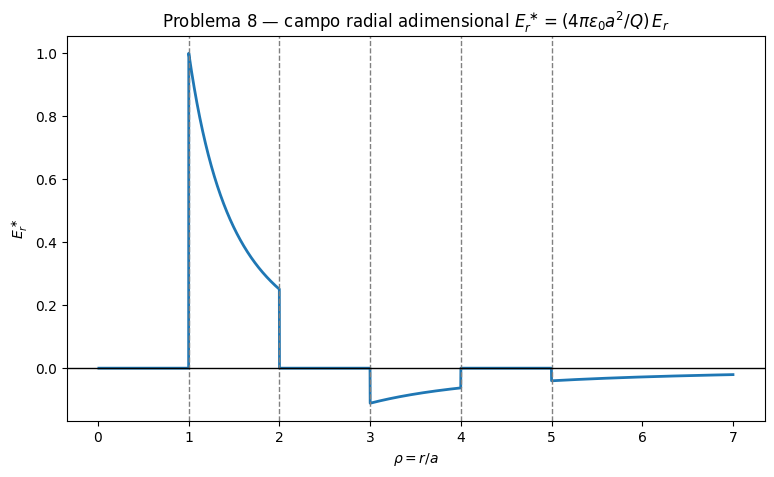

In [22]:
def E_star(rho):
    # Campo radial adimensional: E* = (4 pi eps0 a^2 / Q) E_r.
    rho = np.asarray(rho)
    out = np.zeros_like(rho, dtype=float)

    reg = (rho > 1) & (rho < 2)
    out[reg] = 1.0 / rho[reg]**2

    reg = (rho > 3) & (rho < 4)
    out[reg] = -1.0 / rho[reg]**2

    reg = (rho > 5)
    out[reg] = -1.0 / rho[reg]**2

    return out

rho = np.linspace(0.01, 7.0, 4000)
Estar = E_star(rho)

plt.figure(figsize=(9,5))
plt.plot(rho, Estar, lw=2)
for rr in [1,2,3,4,5]:
    plt.axvline(rr, color='gray', ls='--', lw=1)

plt.axhline(0, color='black', lw=1)
plt.xlabel(r"$\rho=r/a$")
plt.ylabel(r"$E_r^\ast$")
plt.title(r"Problema 8 — campo radial adimensional $E_r^\ast=(4\pi\varepsilon_0 a^2/Q)\,E_r$")
plt.show()

### Figura 8.6 — magnitud del campo radial

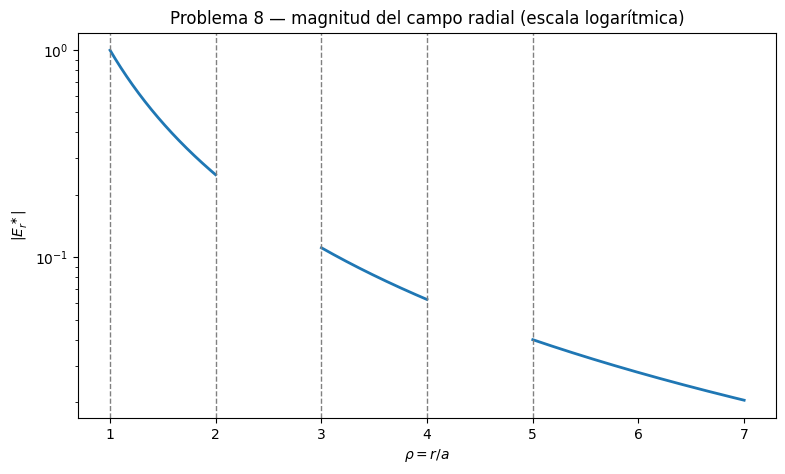

In [23]:
Estar_mag = np.abs(Estar)
Estar_mag[Estar_mag == 0] = np.nan

plt.figure(figsize=(9,5))
plt.plot(rho, Estar_mag, lw=2)
for rr in [1,2,3,4,5]:
    plt.axvline(rr, color='gray', ls='--', lw=1)

plt.yscale('log')
plt.xlabel(r"$\rho=r/a$")
plt.ylabel(r"$|E_r^\ast|$")
plt.title("Problema 8 — magnitud del campo radial (escala logarítmica)")
plt.show()